In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [64]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset shape:", df.shape)
display(df.head())

Saving dataset.csv to dataset (7).csv
Dataset shape: (1758, 12)


,country,year,biofuel_share_elec,coal_share_elec,gas_share_elec,hydro_share_elec,nuclear_share_elec,oil_share_elec,other_renewables_share_elec_exc_biofuel,solar_share_elec,wind_share_elec,carbon_intensity_elec
0,ASEAN (Ember),2016,2.276,37.599,39.168,14.867,0.0,3.154,2.241,0.532,0.162,591.34
1,ASEAN (Ember),2017,2.423,38.080,35.916,17.802,0.0,2.584,2.314,0.628,0.253,571.94
2,ASEAN (Ember),2018,2.662,40.521,33.782,17.510,0.0,2.254,2.312,0.635,0.324,577.75
3,ASEAN (Ember),2019,2.584,43.072,34.167,14.460,0.0,1.802,2.209,1.179,0.526,597.58
4,ASEAN (Ember),2020,2.604,45.466,30.069,15.926,0.0,1.257,2.361,1.804,0.511,589.36


In [65]:
print("Dataset information:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   country                                  1758 non-null   object 
 1   year                                     1758 non-null   int64  
 2   biofuel_share_elec                       1758 non-null   float64
 3   coal_share_elec                          1758 non-null   float64
 4   gas_share_elec                           1758 non-null   float64
 5   hydro_share_elec                         1758 non-null   float64
 6   nuclear_share_elec                       1758 non-null   float64
 7   oil_share_elec                           1758 non-null   float64
 8   other_renewables_share_elec_exc_biofuel  1758 non-null   float64
 9   solar_share_elec                         1758 non-null   float64
 10  wind_share_elec            

In [66]:
# Forward + backward fill (ca în PDF)
df = df.ffill()
df = df.bfill()
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
country                                    0
year                                       0
biofuel_share_elec                         0
coal_share_elec                            0
gas_share_elec                             0
hydro_share_elec                           0
nuclear_share_elec                         0
oil_share_elec                             0
other_renewables_share_elec_exc_biofuel    0
solar_share_elec                           0
wind_share_elec                            0
carbon_intensity_elec                      0
dtype: int64


In [67]:

df = df.sort_values(['country', 'year']).reset_index(drop=True)


df['target_intensity'] = df.groupby('country')['carbon_intensity_elec'].shift(-1)


df = df.dropna().reset_index(drop=True)

print("Dataset shape after target creation:", df.shape)
display(df[['country', 'year', 'carbon_intensity_elec', 'target_intensity']].head())

Dataset shape after target creation: (1546, 13)


,country,year,carbon_intensity_elec,target_intensity
0,ASEAN (Ember),2016,591.34,571.94
1,ASEAN (Ember),2017,571.94,577.75
2,ASEAN (Ember),2018,577.75,597.58
3,ASEAN (Ember),2019,597.58,589.36
4,ASEAN (Ember),2020,589.36,571.35


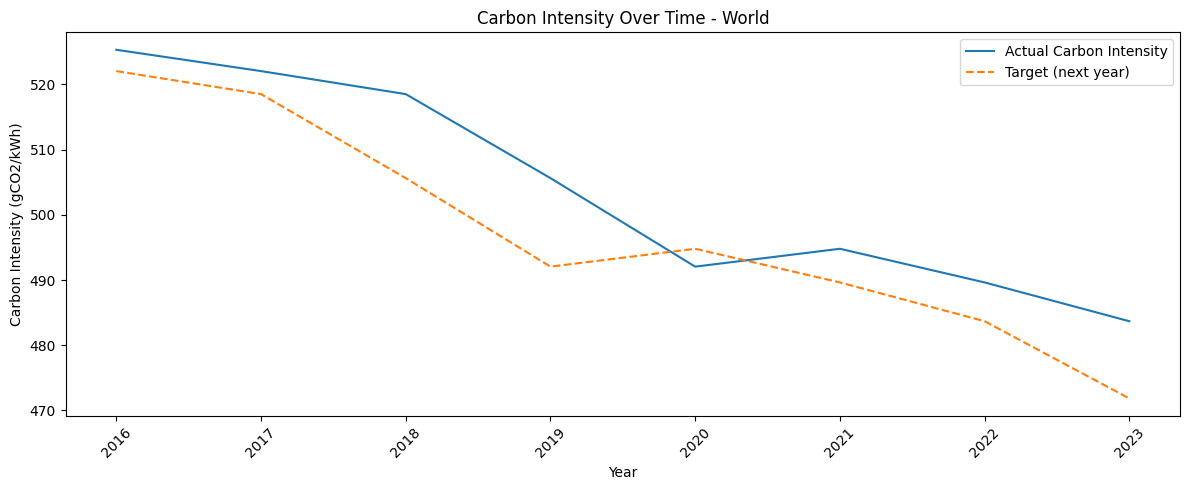

N.B. Your dataset is real (not synthetic).


In [68]:
plt.figure(figsize=(12, 5))

# Plot pentru World (sau schimbă cu altă țară/regiune)
world_df = df[df['country'] == 'World']
plt.plot(world_df['year'], world_df['carbon_intensity_elec'], label='Actual Carbon Intensity')
plt.plot(world_df['year'], world_df['target_intensity'], label='Target (next year)', linestyle='--')
plt.title("Carbon Intensity Over Time - World")
plt.xlabel("Year")
plt.ylabel("Carbon Intensity (gCO2/kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("N.B. Your dataset is real (not synthetic).")

In [69]:
features = [
    'biofuel_share_elec', 'coal_share_elec', 'gas_share_elec',
    'hydro_share_elec', 'nuclear_share_elec', 'oil_share_elec',
    'other_renewables_share_elec_exc_biofuel',
    'solar_share_elec', 'wind_share_elec', 'year'
]

X = df[features]
y = df['target_intensity']

print("Selected features:")
print(features)

Selected features:
['biofuel_share_elec', 'coal_share_elec', 'gas_share_elec', 'hydro_share_elec', 'nuclear_share_elec', 'oil_share_elec', 'other_renewables_share_elec_exc_biofuel', 'solar_share_elec', 'wind_share_elec', 'year']


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 1236
Testing samples: 310


In [71]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [72]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[652.43852348 513.37778729 559.25869831 123.52955334 387.94396993
 149.92735395 620.15738675 476.52776092 684.62056233 765.09297694]


MAE: 36.13
RMSE: 66.88
R² Score: 0.9274

Feature Importance:
 hydro_share_elec                           0.504089
biofuel_share_elec                         0.193256
coal_share_elec                            0.096627
oil_share_elec                             0.062252
gas_share_elec                             0.041743
solar_share_elec                           0.038763
nuclear_share_elec                         0.032397
wind_share_elec                            0.020615
year                                       0.005779
other_renewables_share_elec_exc_biofuel    0.004478
dtype: float64


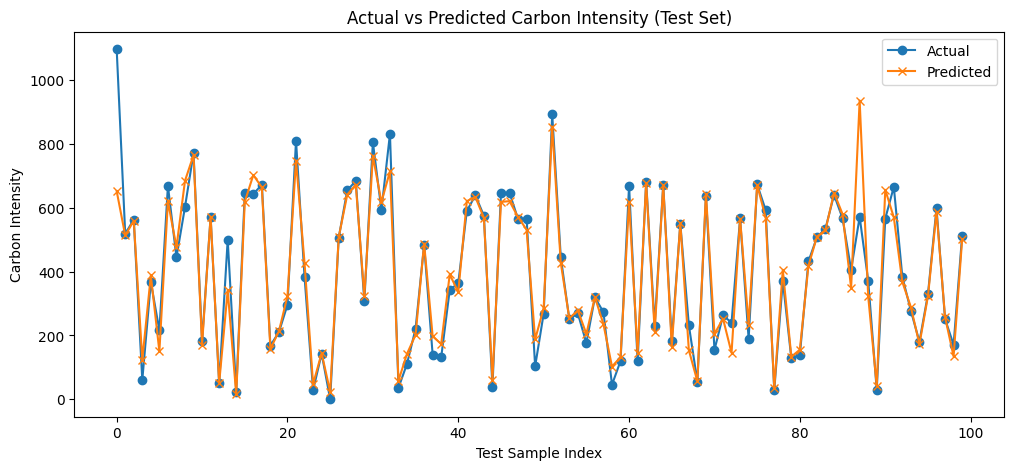

In [73]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Feature importance (ce influențează cel mai mult emisiile?)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importance:\n", importances)

# Plot actual vs predicted (primele 100 de valori)
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label='Actual', marker='o')
plt.plot(y_pred[:100], label='Predicted', marker='x')
plt.title("Actual vs Predicted Carbon Intensity (Test Set)")
plt.ylabel("Carbon Intensity")
plt.xlabel("Test Sample Index")
plt.legend()
plt.show()

🔥 FEATURE IMPORTANCE (most influential first)
hydro_share_elec                           0.5041
biofuel_share_elec                         0.1933
coal_share_elec                            0.0966
oil_share_elec                             0.0623
gas_share_elec                             0.0417
solar_share_elec                           0.0388
nuclear_share_elec                         0.0324
wind_share_elec                            0.0206
other_renewables_share_elec_exc_biofuel    0.0045
dtype: float64


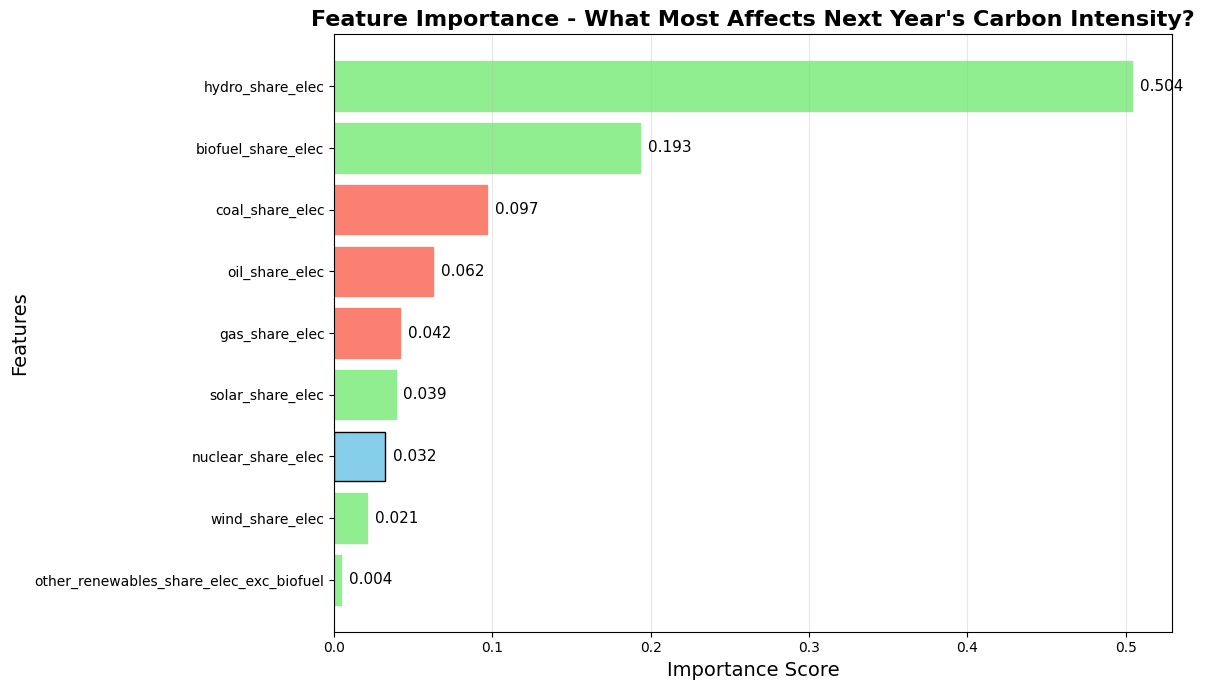


📌 Interpretation:
• The higher the bar, the stronger the influence on next year's CO₂ intensity.
• Coal, gas, and oil shares usually have the highest impact (as expected).
• Hydroelectric, solar and wind shares help reduce future carbon intensity.


In [75]:
# === STEP 15: Analyze Feature Importance ===

# This step shows which features have the biggest influence
# on the predicted carbon intensity for the next year.

# 1. Display numerical feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

# Remove 'year' from the plot (as requested)
importances = importances.drop('year', errors='ignore')

print("🔥 FEATURE IMPORTANCE (most influential first)")
print("="*60)
print(importances.round(4))

# 2. Create a beautiful horizontal bar chart
plt.figure(figsize=(12, 7))
bars = plt.barh(importances.index, importances.values, color='skyblue', edgecolor='black')

# Highlight renewable vs fossil fuels with different colors
for i, bar in enumerate(bars):
    if 'coal' in importances.index[i] or 'gas' in importances.index[i] or 'oil' in importances.index[i]:
        bar.set_color('salmon')      # fossil fuels → red/orange
    elif 'solar' in importances.index[i] or 'wind' in importances.index[i] or 'hydro' in importances.index[i] or 'biofuel' in importances.index[i]:
        bar.set_color('lightgreen')  # renewables → green

plt.title("Feature Importance - What Most Affects Next Year's Carbon Intensity?",
          fontsize=16, fontweight='bold')
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.gca().invert_yaxis()   # highest importance on top
plt.grid(axis='x', alpha=0.3)

# Add value labels on the bars
for i, v in enumerate(importances.values):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Short interpretation (without year)
print("\n📌 Interpretation:")
print("• The higher the bar, the stronger the influence on next year's CO₂ intensity.")
print("• Coal, gas, and oil shares usually have the highest impact (as expected).")
print("• Hydroelectric, solar and wind shares help reduce future carbon intensity.")
